# Parallel Transport and Holonomy

Parallel transport is the operation that lets you compare tangent vectors at different points of a manifold — a prerequisite for message passing in a GNN or convolution on a curved domain. This notebook shows transport along a path, then **holonomy**: a vector carried around a closed loop returns rotated. That rotation is why ambient Euclidean arithmetic is not valid on curved data. Rotate the 3-D scenes to inspect the transported frames.

**Metric-first design.** A HAM `FinslerMetric` is specified by a single scalar field, the Finsler cost
$F(x, v)$, which defines the path energy
$$\mathcal{E}[\gamma] = \int \tfrac{1}{2}\, F^2(x, \dot{x})\, dt.$$
The geodesic spray, fundamental tensor, curvature, and Berwald parallel transport are then obtained by
automatic differentiation of $F$ with `jax.grad` / `jax.hessian`, rather than by hand-deriving
Christoffel symbols. The notebooks in this suite share a small plotting style (`ham.vis.style`) so the
figures stay consistent and readable.

## 1. Setup

`Manifold.parallel_transport(x, y, v)` carries a tangent vector $v \in T_xM$ along the geodesic to $y$,
giving a vector in $T_yM$. For the sphere this is the exact Levi-Civita transport; for a general Finsler
metric the analogue is the Berwald connection (`ham.geometry.BerwaldConnection`), derived from the spray.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

from ham.geometry import Sphere
from ham.vis.style import (use_ham_style, PALETTE, plotly_layout, plotly_sphere,
                           plotly_path, plotly_cones)

pio.renderers.default = "plotly_mimetype"
use_ham_style()
sphere = Sphere(radius=1.0)

## 2. Transporting a vector along a path

We transport a vector along a geodesic, one segment at a time. It keeps a constant angle to the path
tangent — the defining property of parallel transport. The cones mark the transported vector at samples
along the curve.

In [2]:
def geodesic(p, q, n=60):
    v = sphere.log_map(p, q)
    ts = jnp.linspace(0, 1, n)
    return jax.vmap(lambda t: sphere.exp_map(p, t * v))(ts)


def transport_along(path, v0):
    def step(v, idx):
        v_new = sphere.parallel_transport(path[idx], path[idx + 1], v)
        return v_new, v_new
    _, vs = jax.lax.scan(step, v0, jnp.arange(path.shape[0] - 1))
    return jnp.concatenate([v0[None], vs], axis=0)


start = jnp.array([1.0, 0.0, 0.0])
end = jnp.array([0.0, 0.6, 0.8]); end = end / jnp.linalg.norm(end)
path = geodesic(start, end, n=60)
v0 = sphere.to_tangent(start, jnp.array([0.0, 1.0, 0.0])); v0 = v0 / jnp.linalg.norm(v0)
vecs = np.array(transport_along(path, v0))
P = np.array(path)
s = slice(0, len(P), 5)

fig = go.Figure()
fig.add_trace(plotly_sphere(1.0))
fig.add_trace(plotly_path(P, color=PALETTE["ink"], name="geodesic", width=5, show_start=False))
fig.add_trace(plotly_cones(P[s], vecs[s], name="transported vector", sizeref=0.45,
                           color=PALETTE["primary"]))
plotly_layout(fig, "Parallel transport along a geodesic")
fig.show()

## 3. Holonomy on a closed loop

We transport a vector around a spherical triangle: equator point $A$ → equator point $B$ → north pole
$N$ → back to $A$, each leg a geodesic. On a flat space the vector would return unchanged; on the sphere
it returns rotated by the enclosed area (Gauss–Bonnet). For this octant the area is $\pi/2$, so we expect
a $90^\circ$ rotation. The blue and orange cones at $A$ are the initial and returned vectors.

In [3]:
A = jnp.array([1.0, 0.0, 0.0])
B = jnp.array([0.0, 1.0, 0.0])
N = jnp.array([0.0, 0.0, 1.0])
loop = jnp.concatenate([geodesic(A, B, 40), geodesic(B, N, 40), geodesic(N, A, 40)], axis=0)

v_init = sphere.to_tangent(A, jnp.array([0.0, 1.0, 0.0])); v_init = v_init / jnp.linalg.norm(v_init)
loop_vecs = np.array(transport_along(loop, v_init))
v_final = loop_vecs[-1]
cos_ang = float(np.dot(v_init, v_final) / (np.linalg.norm(v_init) * np.linalg.norm(v_final)))
holonomy_deg = np.degrees(np.arccos(np.clip(cos_ang, -1, 1)))
print(f"initial vector : {np.round(np.array(v_init), 3)}")
print(f"returned vector: {np.round(v_final, 3)}")
print(f"holonomy angle : {holonomy_deg:.2f} deg   (enclosed area = pi/2 -> 90)")

L = np.array(loop)
s = slice(0, len(L), 7)
fig = go.Figure()
fig.add_trace(plotly_sphere(1.0))
fig.add_trace(plotly_path(L, color=PALETTE["ink"], name="closed loop", width=5, show_start=False))
fig.add_trace(plotly_cones(L[s], loop_vecs[s], name="transported", sizeref=0.4, color=PALETTE["teal"]))
fig.add_trace(plotly_cones(np.array(A)[None], v_init[None], name="initial", sizeref=0.2,
                           color=PALETTE["primary"]))
fig.add_trace(plotly_cones(np.array(A)[None], v_final[None], name="returned", sizeref=0.2,
                           color=PALETTE["accent"]))
plotly_layout(fig, f"Holonomy: the vector returns rotated by {holonomy_deg:.0f} degrees")
fig.show()

initial vector : [0. 1. 0.]
returned vector: [ 0. -0.  1.]
holonomy angle : 90.00 deg   (enclosed area = pi/2 -> 90)


## 4. Holonomy is proportional to enclosed area

Gauss–Bonnet predicts the holonomy of a geodesic loop on the unit sphere equals the solid angle it
encloses. We confirm it by transporting around latitude circles of growing size: a small loop gives
little holonomy, a large loop gives a large rotation.

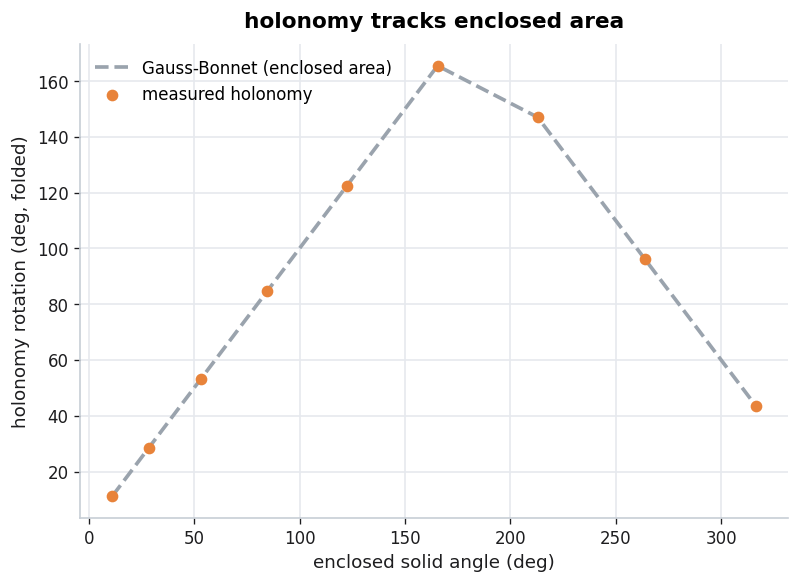

In [4]:
def cap_loop(theta_cap, n=120):
    phi = jnp.linspace(0, 2 * jnp.pi, n)
    r = jnp.sin(theta_cap)
    return jnp.stack([r * jnp.cos(phi), r * jnp.sin(phi),
                      jnp.cos(theta_cap) * jnp.ones_like(phi)], axis=1)


caps = np.linspace(0.25, 1.45, 9)
measured, enclosed = [], []
for tc in caps:
    lp = cap_loop(tc)
    v0c = sphere.to_tangent(lp[0], jnp.array([0.0, 0.0, 1.0])); v0c = v0c / jnp.linalg.norm(v0c)
    vend = np.array(transport_along(lp, v0c))[-1]
    ca = float(np.dot(v0c, vend) / (np.linalg.norm(v0c) * np.linalg.norm(vend)))
    measured.append(np.degrees(np.arccos(np.clip(ca, -1, 1))))
    enclosed.append(np.degrees(2 * np.pi * (1 - np.cos(tc))))

measured = np.minimum(np.array(measured), 360 - np.array(measured))
predicted = np.minimum(np.array(enclosed), 360 - np.array(enclosed))

fig, ax = plt.subplots(figsize=(6.8, 5))
ax.plot(enclosed, predicted, "--", color=PALETTE["muted"], label="Gauss-Bonnet (enclosed area)")
ax.scatter(enclosed, measured, color=PALETTE["accent"], zorder=5, label="measured holonomy")
ax.set_xlabel("enclosed solid angle (deg)"); ax.set_ylabel("holonomy rotation (deg, folded)")
ax.set_title("holonomy tracks enclosed area"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Why this matters for ML

* To compare or aggregate tangent features at different manifold points (attention scores, GNN messages,
  flow on a sphere), transport them to a common tangent space first; ambient subtraction is not
  meaningful.
* Holonomy is the obstruction that makes a curved space curved: there is no global frame in which
  transport is trivial. Methods that ignore it accumulate error proportional to the curvature.
* HAM provides both the Riemannian transport used here (`Manifold.parallel_transport`) and the
  Finslerian Berwald transport (`BerwaldConnection`) for asymmetric or learned metrics, from the same
  scalar $F$.